In [1]:
import os
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

# --------------------------------------------------
# Reproducibility
# --------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --------------------------------------------------
# Device
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --------------------------------------------------
# Project paths
# --------------------------------------------------
PROJECT_ROOT = Path("..").resolve()

ACTIVITY_DIR = PROJECT_ROOT / "results" / "activity_analysis"
THERMAL_DIR  = PROJECT_ROOT / "results" / "thermal_modeling"
CNN_PINN_DIR = PROJECT_ROOT / "results" / "cnn_pinn"

CNN_PINN_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Load thermal/activity summaries from previous notebooks
# --------------------------------------------------
activity_summary_path = ACTIVITY_DIR / "activity_summary.csv"
thermal_summary_path  = THERMAL_DIR / "thermal_summary.csv"

if not activity_summary_path.exists():
    raise FileNotFoundError(
        f"Missing activity summary: {activity_summary_path}\n"
        "Run Notebook 1 first."
    )

if not thermal_summary_path.exists():
    raise FileNotFoundError(
        f"Missing thermal summary: {thermal_summary_path}\n"
        "Run Notebook 2 first."
    )

activity_df = pd.read_csv(activity_summary_path)
thermal_df  = pd.read_csv(thermal_summary_path)

print("Loaded activity summary:", activity_summary_path)
print("Loaded thermal summary :", thermal_summary_path)
print("Activity cases:", len(activity_df))
print("Thermal cases :", len(thermal_df))

# --------------------------------------------------
# Problem setting
# --------------------------------------------------
# First target: steady-state CNN-PINN
# Learn:
#   Q(x, y) -> T_final(x, y)
#
# We start with a fixed training size (16x16) because:
# - enough spatial structure
# - easy batching
# - natural bridge to larger sizes later
#
# Later, we extend to:
#   32, 64, 128, 256
# using synthetic activity generation + thermal solver.
# --------------------------------------------------
TRAIN_N = 16
T_AMB = 25.0

print("\nCNN-PINN setup:")
print("Target task : steady-state thermal prediction")
print("Mapping     : Q(x,y) -> T_final(x,y)")
print("Train size  :", TRAIN_N)
print("Ambient T   :", T_AMB)

# --------------------------------------------------
# Quick preview of available 16x16 anchor cases
# --------------------------------------------------
anchor_df = thermal_df[thermal_df["N"] == TRAIN_N].copy().sort_values(["architecture", "workload"])
print("\nAvailable hardware-grounded anchor cases at 16x16:")
display(anchor_df)

Using device: cuda
Loaded activity summary: /home/aditya_chaudhry/thermal_aware_mac/results/activity_analysis/activity_summary.csv
Loaded thermal summary : /home/aditya_chaudhry/thermal_aware_mac/results/thermal_modeling/thermal_summary.csv
Activity cases: 24
Thermal cases : 24

CNN-PINN setup:
Target task : steady-state thermal prediction
Mapping     : Q(x,y) -> T_final(x,y)
Train size  : 16
Ambient T   : 25.0

Available hardware-grounded anchor cases at 16x16:


,architecture,workload,N,shape,heat_scale,peak_temp,min_temp,avg_temp,temp_gradient
9,standard,checkerboard,16,16x16,0.1,27.079296,26.850351,26.964821,0.228945
10,standard,hotspot,16,16x16,0.1,28.570538,25.028433,25.982410,3.542105
11,standard,uniform,16,16x16,0.1,28.929646,28.929646,28.929649,0.000000
21,systolic,checkerboard,16,16x16,0.1,29.306564,27.752834,28.377037,1.553730
22,systolic,hotspot,16,16x16,0.1,30.626827,25.437204,28.794584,5.189623
23,systolic,uniform,16,16x16,0.1,33.621582,30.564207,31.772503,3.057375


Loaded anchor cases: 6
standard | checkerboard | A shape=(16, 16) | T shape=(16, 16)
standard | hotspot      | A shape=(16, 16) | T shape=(16, 16)
standard | uniform      | A shape=(16, 16) | T shape=(16, 16)
systolic | checkerboard | A shape=(16, 16) | T shape=(16, 16)
systolic | hotspot      | A shape=(16, 16) | T shape=(16, 16)
systolic | uniform      | A shape=(16, 16) | T shape=(16, 16)

Dataset strategy:
1. Use the 16x16 RTL/VCD-derived cases as hardware-grounded anchor samples.
2. Generate many additional synthetic 16x16 activity maps.
3. Run the thermal solver to produce target temperature maps.
4. Train a steady-state CNN-PINN on:
      Q(x,y) -> T_final(x,y)
5. Later extend the same idea to 32, 64, 128, 256.


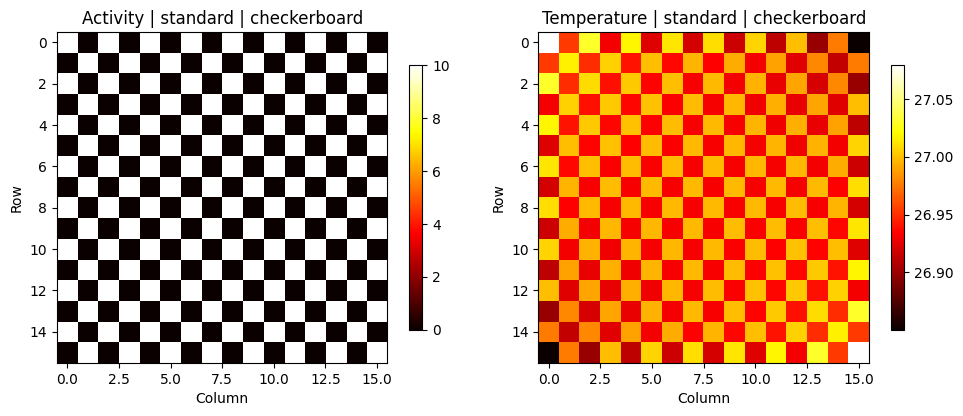

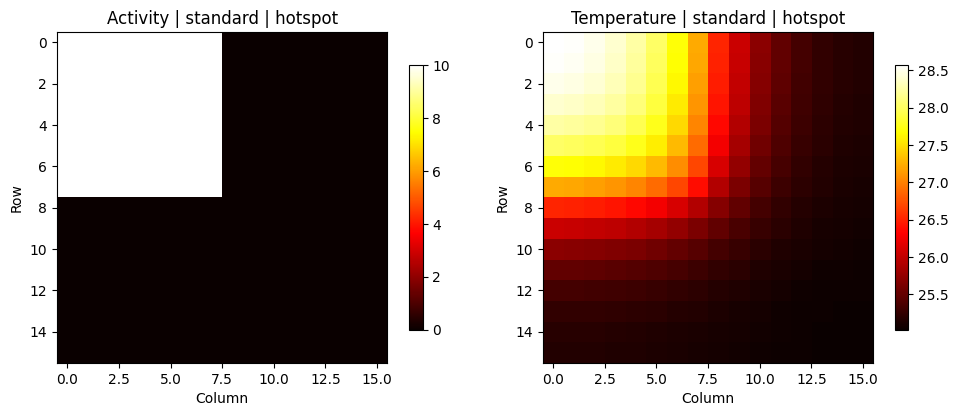

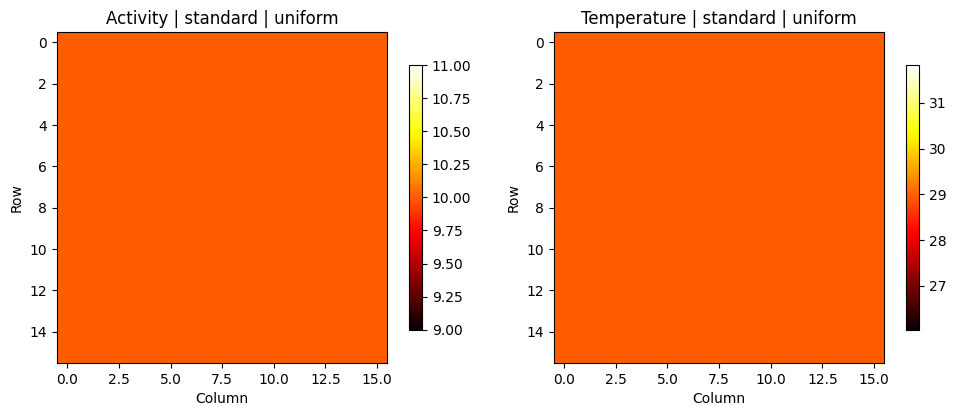

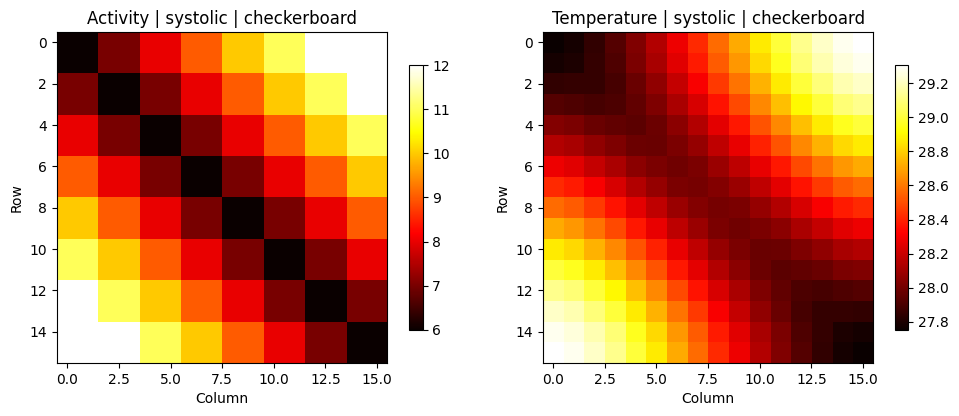

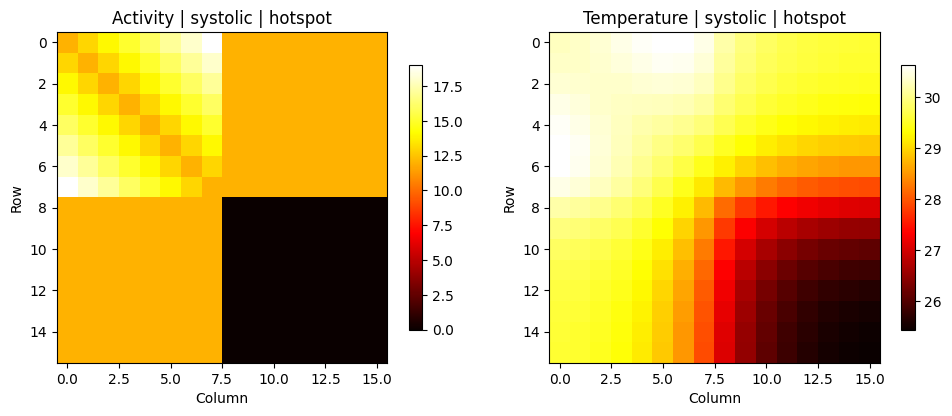

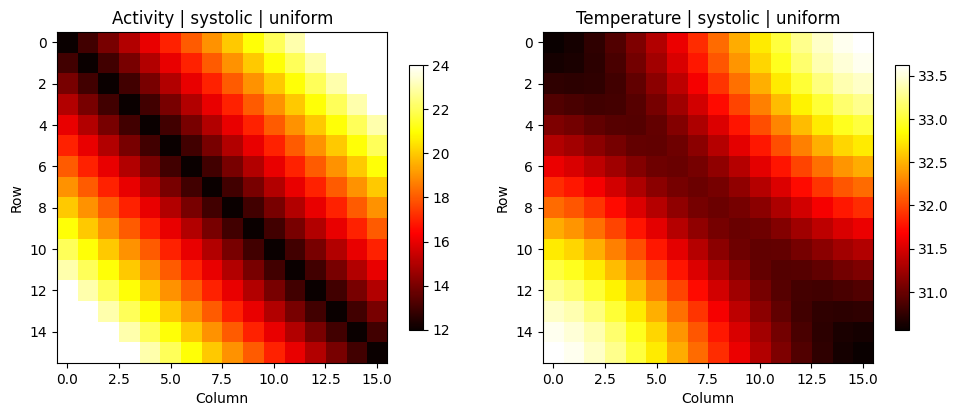

In [2]:
# --------------------------------------------------
# Helper loaders for anchor maps
# --------------------------------------------------
def load_activity_matrix(architecture, N, workload):
    path = ACTIVITY_DIR / architecture / f"{N}x{N}" / workload / "activity_matrix.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing activity matrix: {path}")
    return pd.read_csv(path).values.astype(np.float32)


def load_final_temperature_map(architecture, N, workload):
    path = THERMAL_DIR / architecture / f"{N}x{N}" / workload / "final_temperature_map.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing final temperature map: {path}")
    return pd.read_csv(path).values.astype(np.float32)


# --------------------------------------------------
# Load real hardware-grounded anchor cases at TRAIN_N
# --------------------------------------------------
anchor_cases = []

for _, row in anchor_df.iterrows():
    arch = row["architecture"]
    workload = row["workload"]
    N = int(row["N"])

    A = load_activity_matrix(arch, N, workload)
    T = load_final_temperature_map(arch, N, workload)

    if A.shape != (TRAIN_N, TRAIN_N):
        raise ValueError(f"Unexpected activity shape for {(arch, N, workload)}: {A.shape}")
    if T.shape != (TRAIN_N, TRAIN_N):
        raise ValueError(f"Unexpected thermal shape for {(arch, N, workload)}: {T.shape}")

    anchor_cases.append({
        "architecture": arch,
        "workload": workload,
        "N": N,
        "activity": A,
        "temperature": T,
    })

print(f"Loaded anchor cases: {len(anchor_cases)}")

for case in anchor_cases:
    print(
        f"{case['architecture']:>8} | "
        f"{case['workload']:<12} | "
        f"A shape={case['activity'].shape} | "
        f"T shape={case['temperature'].shape}"
    )


# --------------------------------------------------
# CNN-PINN data strategy
# --------------------------------------------------
print("\nDataset strategy:")
print("1. Use the 16x16 RTL/VCD-derived cases as hardware-grounded anchor samples.")
print("2. Generate many additional synthetic 16x16 activity maps.")
print("3. Run the thermal solver to produce target temperature maps.")
print("4. Train a steady-state CNN-PINN on:")
print("      Q(x,y) -> T_final(x,y)")
print("5. Later extend the same idea to 32, 64, 128, 256.")


# --------------------------------------------------
# Quick visual preview of anchor cases
# --------------------------------------------------
def preview_anchor_case(case, cmap_activity="hot", cmap_temp="hot"):
    A = case["activity"]
    T = case["temperature"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    im0 = axes[0].imshow(A, interpolation="nearest", cmap=cmap_activity)
    axes[0].set_title(f"Activity | {case['architecture']} | {case['workload']}")
    axes[0].set_xlabel("Column")
    axes[0].set_ylabel("Row")
    fig.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(T, interpolation="nearest", cmap=cmap_temp)
    axes[1].set_title(f"Temperature | {case['architecture']} | {case['workload']}")
    axes[1].set_xlabel("Column")
    axes[1].set_ylabel("Row")
    fig.colorbar(im1, ax=axes[1], shrink=0.8)

    plt.tight_layout()
    plt.show()


# Preview all six real anchor cases
for case in anchor_cases:
    preview_anchor_case(case)

Synthetic cases generated: 600
Real anchor cases: 6
Total training pool size: 606


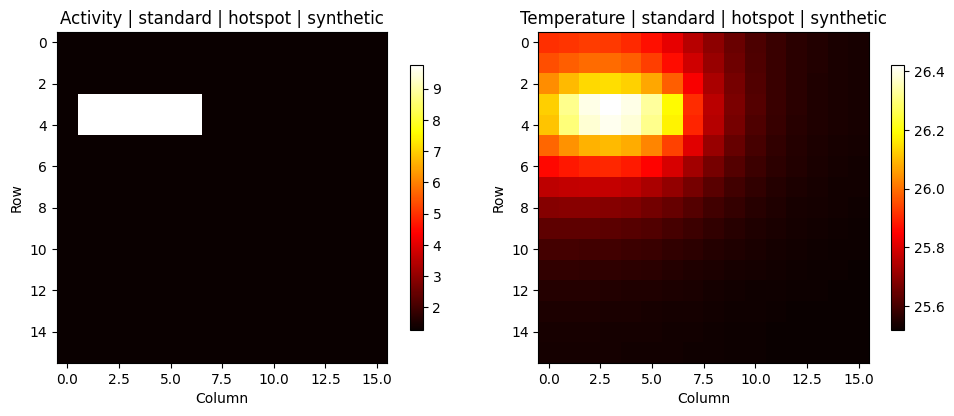

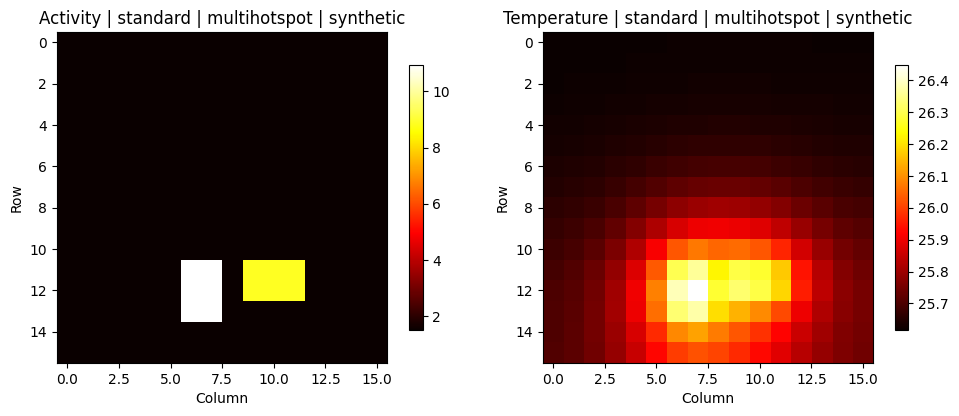

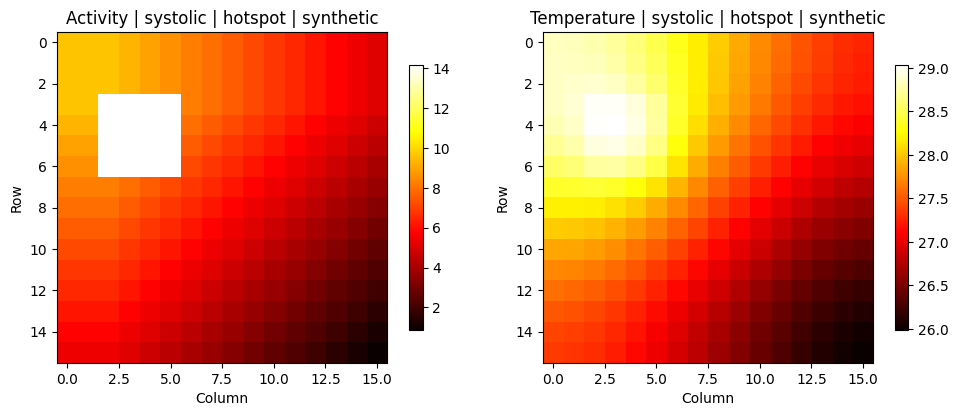

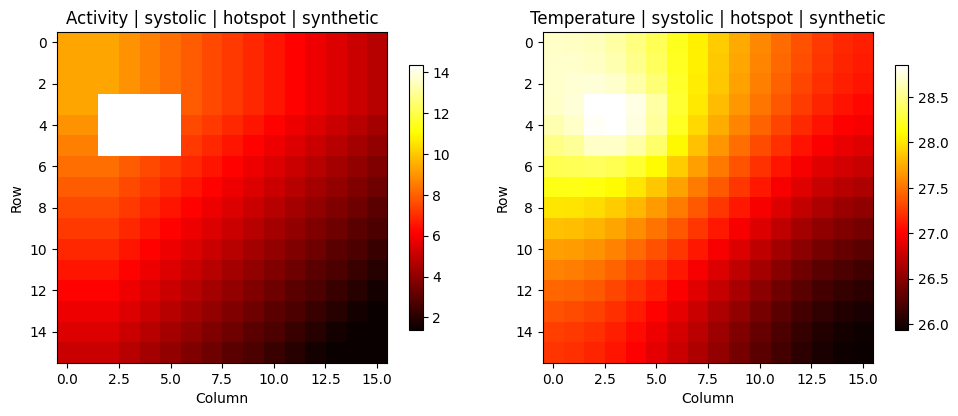

In [3]:
# --------------------------------------------------
# Thermal physics constants (same as Notebook 2)
# --------------------------------------------------
ALPHA = 0.15
BETA  = 0.08
GAMMA = 0.02
T_AMB = 25.0

# --------------------------------------------------
# Converged steady-state thermal solver
# --------------------------------------------------
def solve_steady_state_temperature(
    Q,
    max_steps=2000,
    tol=1e-5,
    T_amb=T_AMB,
    alpha=ALPHA,
    beta=BETA,
    gamma=GAMMA
):
    """
    Solve for steady-state temperature using the same finite-difference
    update rule as the original simulator, but iterate until convergence.

    Q: heat source (N x N)
    returns: final steady-state temperature map (N x N)
    """
    N = Q.shape[0]
    T = np.full((N, N), T_amb, dtype=np.float32)

    for _ in range(max_steps):
        T_new = T.copy()

        for i in range(N):
            for j in range(N):
                neighbors = 0.0
                count = 0

                if i > 0:
                    neighbors += T[i - 1, j]
                    count += 1
                if i < N - 1:
                    neighbors += T[i + 1, j]
                    count += 1
                if j > 0:
                    neighbors += T[i, j - 1]
                    count += 1
                if j < N - 1:
                    neighbors += T[i, j + 1]
                    count += 1

                lap = neighbors - count * T[i, j]

                T_new[i, j] = (
                    T[i, j]
                    + alpha * lap
                    + beta * Q[i, j]
                    - gamma * (T[i, j] - T_amb)
                )

        max_delta = np.max(np.abs(T_new - T))
        T = T_new

        if max_delta < tol:
            break

    return T.astype(np.float32)


# --------------------------------------------------
# Synthetic activity generators for 16x16
# --------------------------------------------------
def gen_standard_uniform(N, rng, level_range=(8.0, 12.0)):
    level = rng.uniform(*level_range)
    return np.full((N, N), level, dtype=np.float32)


def gen_standard_checkerboard(N, rng, high_range=(8.0, 12.0), low_range=(0.0, 1.0)):
    high = rng.uniform(*high_range)
    low = rng.uniform(*low_range)
    A = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        for j in range(N):
            A[i, j] = high if ((i + j) % 2 == 0) else low
    return A


def gen_standard_hotspot(N, rng, hot_range=(8.0, 12.0), bg_range=(0.0, 1.5)):
    hot = rng.uniform(*hot_range)
    bg = rng.uniform(*bg_range)

    A = np.full((N, N), bg, dtype=np.float32)

    h = int(rng.integers(max(2, N // 6), max(3, N // 2)))
    w = int(rng.integers(max(2, N // 6), max(3, N // 2)))
    r0 = int(rng.integers(0, N - h + 1))
    c0 = int(rng.integers(0, N - w + 1))

    A[r0:r0 + h, c0:c0 + w] = hot
    return A


def gen_standard_multihotspot(N, rng, n_hotspots=2, hot_range=(7.0, 12.0), bg_range=(0.0, 2.0)):
    A = np.full((N, N), rng.uniform(*bg_range), dtype=np.float32)

    for _ in range(n_hotspots):
        hot = rng.uniform(*hot_range)
        h = int(rng.integers(max(2, N // 8), max(3, N // 4)))
        w = int(rng.integers(max(2, N // 8), max(3, N // 4)))
        r0 = int(rng.integers(0, N - h + 1))
        c0 = int(rng.integers(0, N - w + 1))
        A[r0:r0 + h, c0:c0 + w] = hot

    return A


def gen_systolic_uniform(N, rng, low_range=(10.0, 14.0), slope_range=(0.15, 0.6)):
    base = rng.uniform(*low_range)
    slope = rng.uniform(*slope_range)

    A = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        for j in range(N):
            A[i, j] = base + slope * abs(i - j) + 0.05 * (i + j)
    return A.astype(np.float32)


def gen_systolic_checkerboard(N, rng, low_range=(6.0, 8.0), high_range=(8.0, 12.0)):
    low = rng.uniform(*low_range)
    high = rng.uniform(*high_range)

    A = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        for j in range(N):
            band = 0.25 * abs(i - j)
            parity = high if ((i + j) % 2 == 0) else low
            A[i, j] = parity + band
    return A.astype(np.float32)


def gen_systolic_hotspot(N, rng, hot_range=(12.0, 18.0), mid_range=(8.0, 12.0), low_range=(0.0, 1.5)):
    A = np.full((N, N), rng.uniform(*low_range), dtype=np.float32)

    hot = rng.uniform(*hot_range)
    mid = rng.uniform(*mid_range)

    h = int(rng.integers(max(2, N // 6), max(3, N // 2)))
    w = int(rng.integers(max(2, N // 6), max(3, N // 2)))

    r0 = int(rng.integers(0, max(1, N // 4)))
    c0 = int(rng.integers(0, max(1, N // 4)))

    A[r0:r0 + h, c0:c0 + w] = hot

    for i in range(N):
        for j in range(N):
            dist = max(0, i - r0) + max(0, j - c0)
            spread = max(0.0, mid - 0.35 * dist)
            A[i, j] = max(A[i, j], spread)

    return A.astype(np.float32)


def gen_activity_sample(N, architecture, rng):
    if architecture == "standard":
        mode = rng.choice(
            ["uniform", "checkerboard", "hotspot", "multihotspot"],
            p=[0.25, 0.25, 0.35, 0.15]
        )
        if mode == "uniform":
            A = gen_standard_uniform(N, rng)
        elif mode == "checkerboard":
            A = gen_standard_checkerboard(N, rng)
        elif mode == "hotspot":
            A = gen_standard_hotspot(N, rng)
        else:
            A = gen_standard_multihotspot(N, rng)

    elif architecture == "systolic":
        mode = rng.choice(
            ["uniform", "checkerboard", "hotspot"],
            p=[0.35, 0.25, 0.40]
        )
        if mode == "uniform":
            A = gen_systolic_uniform(N, rng)
        elif mode == "checkerboard":
            A = gen_systolic_checkerboard(N, rng)
        else:
            A = gen_systolic_hotspot(N, rng)

    else:
        raise ValueError(f"Unknown architecture: {architecture}")

    return A.astype(np.float32), {"architecture": architecture, "pattern": mode}


# --------------------------------------------------
# Build synthetic training dataset
# --------------------------------------------------
SYNTH_PER_ARCH = 300
rng = np.random.default_rng(SEED)

synthetic_cases = []

for architecture in ["standard", "systolic"]:
    for _ in range(SYNTH_PER_ARCH):
        A, meta = gen_activity_sample(TRAIN_N, architecture, rng)

        Q = 0.1 * A.astype(np.float32)
        T_final = solve_steady_state_temperature(Q)

        synthetic_cases.append({
            "architecture": architecture,
            "workload": meta["pattern"],
            "N": TRAIN_N,
            "activity": A,
            "temperature": T_final,
            "source": "synthetic",
        })

print("Synthetic cases generated:", len(synthetic_cases))


# --------------------------------------------------
# Convert real anchor cases into same schema
# --------------------------------------------------
real_anchor_cases = []
for case in anchor_cases:
    real_anchor_cases.append({
        "architecture": case["architecture"],
        "workload": case["workload"],
        "N": case["N"],
        "activity": case["activity"].astype(np.float32),
        "temperature": case["temperature"].astype(np.float32),
        "source": "anchor_real",
    })

print("Real anchor cases:", len(real_anchor_cases))


# --------------------------------------------------
# Final pool
# --------------------------------------------------
all_cases = synthetic_cases + real_anchor_cases
print("Total training pool size:", len(all_cases))


# --------------------------------------------------
# Quick preview
# --------------------------------------------------
def preview_case(case, cmap_activity="hot", cmap_temp="hot"):
    A = case["activity"]
    T = case["temperature"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    im0 = axes[0].imshow(A, interpolation="nearest", cmap=cmap_activity)
    axes[0].set_title(f"Activity | {case['architecture']} | {case['workload']} | {case['source']}")
    axes[0].set_xlabel("Column")
    axes[0].set_ylabel("Row")
    fig.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(T, interpolation="nearest", cmap=cmap_temp)
    axes[1].set_title(f"Temperature | {case['architecture']} | {case['workload']} | {case['source']}")
    axes[1].set_xlabel("Column")
    axes[1].set_ylabel("Row")
    fig.colorbar(im1, ax=axes[1], shrink=0.8)

    plt.tight_layout()
    plt.show()


std_examples = [c for c in synthetic_cases if c["architecture"] == "standard"][:2]
sys_examples = [c for c in synthetic_cases if c["architecture"] == "systolic"][:2]

for case in std_examples + sys_examples:
    preview_case(case)

In [4]:
# --------------------------------------------------
# Prepare tensors + metadata
# --------------------------------------------------
X_list = []
Y_list = []
meta_records = []

for case in all_cases:
    A = case["activity"]
    T = case["temperature"]

    Q = 0.1 * A
    dT = T - T_AMB

    X_list.append(Q.astype(np.float32))
    Y_list.append(dT.astype(np.float32))

    meta_records.append({
        "architecture": case["architecture"],
        "workload": case["workload"],
        "N": case["N"],
        "source": case["source"],
    })

X = np.stack(X_list)
Y = np.stack(Y_list)
meta_df = pd.DataFrame(meta_records)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
display(meta_df["source"].value_counts())


# --------------------------------------------------
# Normalize
# --------------------------------------------------
X_mean, X_std = X.mean(), X.std() + 1e-8
Y_mean, Y_std = Y.mean(), Y.std() + 1e-8

X_norm = (X - X_mean) / X_std
Y_norm = (Y - Y_mean) / Y_std

print("\nNormalization:")
print("X_mean:", X_mean, "X_std:", X_std)
print("Y_mean:", Y_mean, "Y_std:", Y_std)


# --------------------------------------------------
# Torch tensors [B, C, H, W]
# --------------------------------------------------
X_tensor = torch.tensor(X_norm, dtype=torch.float32).unsqueeze(1)
Y_tensor = torch.tensor(Y_norm, dtype=torch.float32).unsqueeze(1)

print("\nTensor shapes:")
print("X_tensor:", X_tensor.shape)
print("Y_tensor:", Y_tensor.shape)


# --------------------------------------------------
# Dataset
# --------------------------------------------------
class ThermalDataset(Dataset):
    def __init__(self, X, Y, meta_df):
        self.X = X
        self.Y = Y
        self.meta_df = meta_df.reset_index(drop=True)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

dataset = ThermalDataset(X_tensor, Y_tensor, meta_df)


# --------------------------------------------------
# Split indices by source
# --------------------------------------------------
synthetic_indices = meta_df.index[meta_df["source"] == "synthetic"].tolist()
anchor_indices = meta_df.index[meta_df["source"] == "anchor_real"].tolist()

rng_gen = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(synthetic_indices), generator=rng_gen).tolist()
synthetic_indices = [synthetic_indices[i] for i in perm]

n_syn = len(synthetic_indices)
n_train = int(0.70 * n_syn)
n_val = int(0.15 * n_syn)
n_test = n_syn - n_train - n_val

syn_train_idx = synthetic_indices[:n_train]
syn_val_idx = synthetic_indices[n_train:n_train + n_val]
syn_test_idx = synthetic_indices[n_train + n_val:]

print("\nSynthetic split sizes:")
print("Train:", len(syn_train_idx))
print("Val  :", len(syn_val_idx))
print("Test :", len(syn_test_idx))
print("Anchors:", len(anchor_indices))


# --------------------------------------------------
# Stage-1 loaders (synthetic only)
# --------------------------------------------------
stage1_train_set = torch.utils.data.Subset(dataset, syn_train_idx)
stage1_val_set   = torch.utils.data.Subset(dataset, syn_val_idx)
stage1_test_set  = torch.utils.data.Subset(dataset, syn_test_idx)

# --------------------------------------------------
# Stage-2 loaders (fine-tune with anchors added to train)
# --------------------------------------------------
stage2_train_idx = syn_train_idx + anchor_indices
stage2_train_set = torch.utils.data.Subset(dataset, stage2_train_idx)

# Separate anchor eval loader
anchor_eval_set = torch.utils.data.Subset(dataset, anchor_indices)

BATCH_SIZE = 16

stage1_train_loader = DataLoader(stage1_train_set, batch_size=BATCH_SIZE, shuffle=True)
stage1_val_loader   = DataLoader(stage1_val_set, batch_size=BATCH_SIZE, shuffle=False)
stage1_test_loader  = DataLoader(stage1_test_set, batch_size=BATCH_SIZE, shuffle=False)

stage2_train_loader = DataLoader(stage2_train_set, batch_size=BATCH_SIZE, shuffle=True)
anchor_eval_loader  = DataLoader(anchor_eval_set, batch_size=BATCH_SIZE, shuffle=False)

# Keep these aliases so Cell 5 still works unchanged
train_loader = stage1_train_loader
val_loader = stage1_val_loader
test_loader = stage1_test_loader

print("\nLoaders ready:")
print("Stage 1 train batches:", len(stage1_train_loader))
print("Stage 1 val batches  :", len(stage1_val_loader))
print("Stage 2 train batches:", len(stage2_train_loader))
print("Anchor eval batches  :", len(anchor_eval_loader))

X shape: (606, 16, 16)
Y shape: (606, 16, 16)


source
synthetic      600
anchor_real      6
Name: count, dtype: int64


Normalization:
X_mean: 0.73684704 X_std: 0.5338686
Y_mean: 2.9463806 Y_std: 1.9191759

Tensor shapes:
X_tensor: torch.Size([606, 1, 16, 16])
Y_tensor: torch.Size([606, 1, 16, 16])

Synthetic split sizes:
Train: 420
Val  : 90
Test : 90
Anchors: 6

Loaders ready:
Stage 1 train batches: 27
Stage 1 val batches  : 6
Stage 2 train batches: 27
Anchor eval batches  : 1


In [5]:
# --------------------------------------------------
# Cell 5: Multi-scale CNN for steady-state thermal prediction
# Input : Q map      -> shape [B, 1, N, N]
# Output: dT map     -> shape [B, 1, N, N]
# --------------------------------------------------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)


class SmallUNetThermalCNN(nn.Module):
    def __init__(self, in_channels=1, base_channels=32, out_channels=1):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ConvBlock(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(base_channels * 2, base_channels * 4)

        # Decoder
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base_channels * 2, base_channels)

        # Output
        self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)         # [B, C, 16, 16]
        p1 = self.pool1(e1)       # [B, C, 8, 8]

        e2 = self.enc2(p1)        # [B, 2C, 8, 8]
        p2 = self.pool2(e2)       # [B, 2C, 4, 4]

        # Bottleneck
        b = self.bottleneck(p2)   # [B, 4C, 4, 4]

        # Decoder
        u2 = self.up2(b)          # [B, 2C, 8, 8]
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)         # [B, C, 16, 16]
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        out = self.out_conv(d1)   # [B, 1, 16, 16]
        return out


model = SmallUNetThermalCNN(
    in_channels=1,
    base_channels=32,
    out_channels=1
).to(device)

print(model)

# Quick sanity check
xb, yb = next(iter(train_loader))
xb = xb.to(device)

with torch.no_grad():
    pred = model(xb)

print("\nSanity check:")
print("Input batch shape :", xb.shape)
print("Pred batch shape  :", pred.shape)

SmallUNetThermalCNN(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): ConvBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (up2): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=

In [6]:
# --------------------------------------------------
# Thermal physics constants
# --------------------------------------------------
ALPHA = 0.15
BETA  = 0.08
GAMMA = 0.02
T_AMB = 25.0

# --------------------------------------------------
# Solver-matched Laplacian
# --------------------------------------------------
def laplacian_like_solver(dT):
    """
    dT: [B, 1, H, W]
    Matches the same stencil used in the steady-state solver:
    variable neighbor count at boundaries.
    """
    lap = torch.zeros_like(dT)

    # accumulate existing neighbors only
    lap[:, :, 1:, :]  += dT[:, :, :-1, :]   # top neighbor
    lap[:, :, :-1, :] += dT[:, :, 1:, :]    # bottom neighbor
    lap[:, :, :, 1:]  += dT[:, :, :, :-1]   # left neighbor
    lap[:, :, :, :-1] += dT[:, :, :, 1:]    # right neighbor

    count = torch.zeros_like(dT)
    count[:, :, 1:, :]  += 1
    count[:, :, :-1, :] += 1
    count[:, :, :, 1:]  += 1
    count[:, :, :, :-1] += 1

    lap = lap - count * dT
    return lap


def physics_residual(pred_dT, Q):
    """
    Steady-state PDE written on dT = T - T_amb
    """
    lap = laplacian_like_solver(pred_dT)
    return ALPHA * lap + BETA * Q - GAMMA * pred_dT


# --------------------------------------------------
# Extra loss: gradient matching
# --------------------------------------------------
def gradient_loss(pred, target):
    """
    pred, target: normalized dT maps [B, 1, H, W]
    Helps preserve sharp hotspot structure and flat regions.
    """
    dx_pred = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dx_true = target[:, :, :, 1:] - target[:, :, :, :-1]

    dy_pred = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    dy_true = target[:, :, 1:, :] - target[:, :, :-1, :]

    loss_x = torch.mean((dx_pred - dx_true) ** 2)
    loss_y = torch.mean((dy_pred - dy_true) ** 2)

    return loss_x + loss_y


# --------------------------------------------------
# Loss functions
# --------------------------------------------------
mse_loss = nn.MSELoss()

def get_lambda_phys(epoch, warmup_start=20, warmup_end=100, max_lambda=0.2):
    if epoch < warmup_start:
        return 0.0
    elif epoch >= warmup_end:
        return max_lambda
    else:
        frac = (epoch - warmup_start) / (warmup_end - warmup_start)
        return max_lambda * frac


def get_lambda_grad(epoch, warmup_start=0, warmup_end=40, max_lambda=0.1):
    """
    Turn on gradient loss early, but keep it modest.
    """
    if epoch >= warmup_end:
        return max_lambda
    elif epoch <= warmup_start:
        return 0.0
    else:
        frac = (epoch - warmup_start) / (warmup_end - warmup_start)
        return max_lambda * frac


def compute_loss(pred_norm, target_norm, input_norm, epoch):
    """
    pred_norm   : normalized predicted dT
    target_norm : normalized true dT
    input_norm  : normalized Q
    """
    # Data loss in normalized space
    loss_data = mse_loss(pred_norm, target_norm)

    # Gradient loss in normalized space
    loss_grad = gradient_loss(pred_norm, target_norm)

    # Convert back to physical units
    pred_dT = pred_norm * Y_std + Y_mean
    Q = input_norm * X_std + X_mean

    # Physics loss in physical units
    residual = physics_residual(pred_dT, Q)
    loss_phys = torch.mean(residual ** 2)

    lambda_phys = get_lambda_phys(epoch)
    lambda_grad = get_lambda_grad(epoch)

    loss = loss_data + lambda_grad * loss_grad + lambda_phys * loss_phys

    return loss, loss_data, loss_phys, lambda_phys, loss_grad, lambda_grad

In [7]:
# --------------------------------------------------
# Debug check: does the target itself satisfy the PDE?
# --------------------------------------------------
with torch.no_grad():
    xb, yb = next(iter(stage1_val_loader))
    xb = xb.to(device)
    yb = yb.to(device)

    y_dT = yb * Y_std + Y_mean
    Q = xb * X_std + X_mean

    target_res = physics_residual(y_dT, Q)
    target_phys_mse = torch.mean(target_res ** 2).item()

print("Target physics residual MSE:", target_phys_mse)

Target physics residual MSE: 6.389874740442281e-11


Epoch 100/100 | Best post-physics Val Loss: 0.000046 | Best Epoch: 100 | lambda_phys: 0.1975 | lambda_grad: 0.1000 | lr: 0.000125 | stage2-finetune


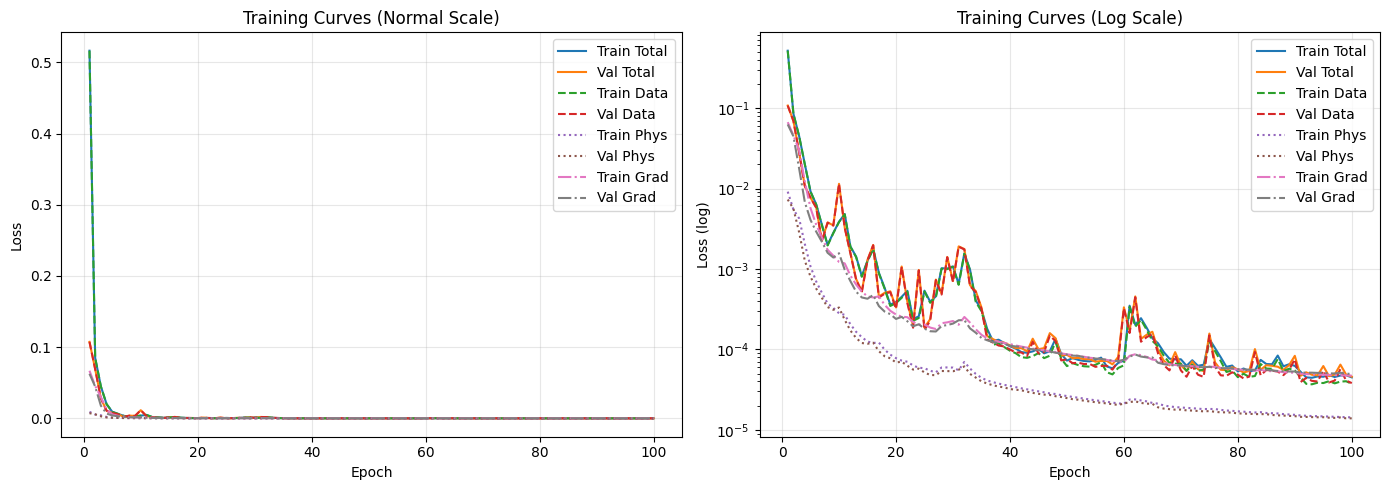

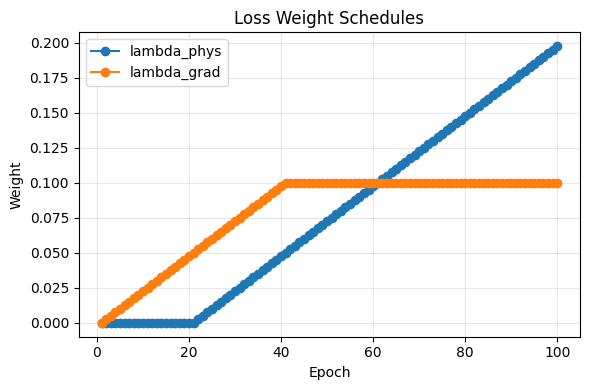

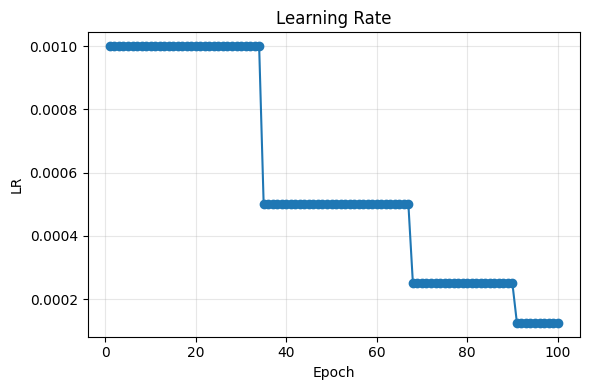

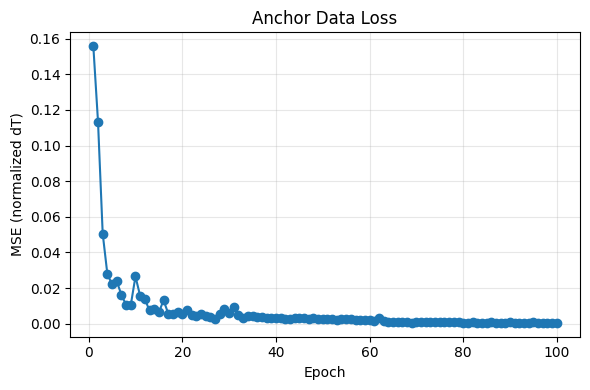


Training complete.
Best post-physics validation loss: 4.584743405252488e-05
Best post-physics epoch: 100


In [8]:
from IPython.display import clear_output
from copy import deepcopy

# --------------------------------------------------
# Stage config
# --------------------------------------------------
STAGE1_EPOCHS = 60
STAGE2_EPOCHS = 40
TOTAL_EPOCHS = STAGE1_EPOCHS + STAGE2_EPOCHS

PLOT_EVERY = 5
GRAD_CLIP = 1.0

# Fresh model / optimizer
model = SmallUNetThermalCNN(
    in_channels=1,
    base_channels=32,
    out_channels=1
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8,
    min_lr=1e-5
)

train_losses = []
train_data_losses = []
train_phys_losses = []
train_grad_losses = []

val_losses = []
val_data_losses = []
val_phys_losses = []
val_grad_losses = []

anchor_data_losses = []

lambda_phys_history = []
lambda_grad_history = []
lr_history = []

best_val_loss = float("inf")
best_state = None
best_epoch = -1


def evaluate(model, loader, epoch):
    model.eval()

    total_loss = 0.0
    total_data = 0.0
    total_phys = 0.0
    total_grad = 0.0
    total_count = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss, loss_data, loss_phys, _, loss_grad, _ = compute_loss(pred, yb, xb, epoch)

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_data += loss_data.item() * bs
            total_phys += loss_phys.item() * bs
            total_grad += loss_grad.item() * bs
            total_count += bs

    return (
        total_loss / total_count,
        total_data / total_count,
        total_phys / total_count,
        total_grad / total_count
    )


def evaluate_data_only(model, loader):
    model.eval()
    total_data = 0.0
    total_count = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss_data = mse_loss(pred, yb)

            bs = xb.size(0)
            total_data += loss_data.item() * bs
            total_count += bs

    return total_data / total_count


def plot_training_progress():
    epochs = np.arange(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, train_losses, label="Train Total")
    axes[0].plot(epochs, val_losses, label="Val Total")
    axes[0].plot(epochs, train_data_losses, "--", label="Train Data")
    axes[0].plot(epochs, val_data_losses, "--", label="Val Data")
    axes[0].plot(epochs, train_phys_losses, ":", label="Train Phys")
    axes[0].plot(epochs, val_phys_losses, ":", label="Val Phys")
    axes[0].plot(epochs, train_grad_losses, "-.", label="Train Grad")
    axes[0].plot(epochs, val_grad_losses, "-.", label="Val Grad")
    axes[0].set_title("Training Curves (Normal Scale)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, train_losses, label="Train Total")
    axes[1].plot(epochs, val_losses, label="Val Total")
    axes[1].plot(epochs, train_data_losses, "--", label="Train Data")
    axes[1].plot(epochs, val_data_losses, "--", label="Val Data")
    axes[1].plot(epochs, train_phys_losses, ":", label="Train Phys")
    axes[1].plot(epochs, val_phys_losses, ":", label="Val Phys")
    axes[1].plot(epochs, train_grad_losses, "-.", label="Train Grad")
    axes[1].plot(epochs, val_grad_losses, "-.", label="Val Grad")
    axes[1].set_yscale("log")
    axes[1].set_title("Training Curves (Log Scale)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss (log)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, lambda_phys_history, marker="o", label="lambda_phys")
    plt.plot(epochs, lambda_grad_history, marker="o", label="lambda_grad")
    plt.title("Loss Weight Schedules")
    plt.xlabel("Epoch")
    plt.ylabel("Weight")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, lr_history, marker="o")
    plt.title("Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, anchor_data_losses, marker="o")
    plt.title("Anchor Data Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (normalized dT)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


for epoch in range(TOTAL_EPOCHS):
    model.train()

    if epoch < STAGE1_EPOCHS:
        active_train_loader = stage1_train_loader
        stage_name = "stage1-synthetic"
    else:
        active_train_loader = stage2_train_loader
        stage_name = "stage2-finetune"

    running_loss = 0.0
    running_data = 0.0
    running_phys = 0.0
    running_grad = 0.0
    total_count = 0

    current_lambda_phys = get_lambda_phys(epoch)
    current_lambda_grad = get_lambda_grad(epoch)

    lambda_phys_history.append(current_lambda_phys)
    lambda_grad_history.append(current_lambda_grad)

    for xb, yb in active_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        pred = model(xb)
        loss, loss_data, loss_phys, _, loss_grad, _ = compute_loss(pred, yb, xb, epoch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        bs = xb.size(0)
        running_loss += loss.item() * bs
        running_data += loss_data.item() * bs
        running_phys += loss_phys.item() * bs
        running_grad += loss_grad.item() * bs
        total_count += bs

    train_loss = running_loss / total_count
    train_data = running_data / total_count
    train_phys = running_phys / total_count
    train_grad = running_grad / total_count

    val_loss, val_data, val_phys, val_grad = evaluate(model, stage1_val_loader, epoch)
    anchor_data = evaluate_data_only(model, anchor_eval_loader)

    train_losses.append(train_loss)
    train_data_losses.append(train_data)
    train_phys_losses.append(train_phys)
    train_grad_losses.append(train_grad)

    val_losses.append(val_loss)
    val_data_losses.append(val_data)
    val_phys_losses.append(val_phys)
    val_grad_losses.append(val_grad)

    anchor_data_losses.append(anchor_data)

    current_lr = optimizer.param_groups[0]["lr"]
    lr_history.append(current_lr)

    if epoch >= 20 and val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = deepcopy(model.state_dict())
        best_epoch = epoch + 1

    scheduler.step(val_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:3d}/{TOTAL_EPOCHS} | {stage_name} | "
            f"lambda_phys: {current_lambda_phys:.4f} | "
            f"lambda_grad: {current_lambda_grad:.4f} | "
            f"lr: {current_lr:.6f} | "
            f"Train: {train_loss:.6f} | "
            f"TrainData: {train_data:.6f} | "
            f"TrainGrad: {train_grad:.6f} | "
            f"TrainPhys: {train_phys:.6f} | "
            f"Val: {val_loss:.6f} | "
            f"ValData: {val_data:.6f} | "
            f"ValGrad: {val_grad:.6f} | "
            f"ValPhys: {val_phys:.6f} | "
            f"AnchorData: {anchor_data:.6f}"
        )

    if (epoch + 1) % PLOT_EVERY == 0 or (epoch + 1) == TOTAL_EPOCHS:
        clear_output(wait=True)
        print(
            f"Epoch {epoch+1:3d}/{TOTAL_EPOCHS} | "
            f"Best post-physics Val Loss: {best_val_loss:.6f} | "
            f"Best Epoch: {best_epoch} | "
            f"lambda_phys: {current_lambda_phys:.4f} | "
            f"lambda_grad: {current_lambda_grad:.4f} | "
            f"lr: {current_lr:.6f} | "
            f"{stage_name}"
        )
        plot_training_progress()

if best_state is not None:
    model.load_state_dict(best_state)
else:
    print("Warning: no post-physics checkpoint was saved.")

print("\nTraining complete.")
print("Best post-physics validation loss:", best_val_loss)
print("Best post-physics epoch:", best_epoch)


Synthetic test set summary
--------------------------
         samples: 90
       MAE(temp): 0.007974
      RMSE(temp): 0.011224
   Max abs error: 0.051306
  Peak abs error: 0.022352
   Avg abs error: 0.003437
  Grad abs error: 0.028929


,split,sample_id,mae_temp,rmse_temp,max_abs_error,peak_true,peak_pred,peak_abs_error,avg_true,avg_pred,avg_abs_error,grad_true,grad_pred,grad_abs_error,architecture,workload,N,source
0,synthetic_test,0,0.004090,0.005015,0.012985,32.833351,32.842827,0.009476,31.697989,31.696541,0.001448,2.003624,2.004688,0.001064,systolic,uniform,16,synthetic
1,synthetic_test,1,0.003617,0.004741,0.020187,29.417778,29.417847,0.000069,28.898903,28.897541,0.001362,0.815540,0.835796,0.020256,systolic,checkerboard,16,synthetic
2,synthetic_test,2,0.004167,0.005410,0.020575,29.633301,29.645924,0.012623,29.633301,29.632912,0.000389,0.000000,0.033197,0.033197,standard,uniform,16,synthetic
3,synthetic_test,3,0.014605,0.019806,0.077028,26.311043,26.352732,0.041689,25.400085,25.397669,0.002417,1.050560,1.087170,0.036610,standard,multihotspot,16,synthetic
4,synthetic_test,4,0.009310,0.014037,0.061501,26.746353,26.748814,0.002460,25.541348,25.540123,0.001225,1.486721,1.495926,0.009205,standard,hotspot,16,synthetic



Real anchor set summary
-----------------------
         samples: 6
       MAE(temp): 0.037231
      RMSE(temp): 0.041237
   Max abs error: 0.089721
  Peak abs error: 0.050561
   Avg abs error: 0.032656
  Grad abs error: 0.033591


,split,sample_id,mae_temp,rmse_temp,max_abs_error,peak_true,peak_pred,peak_abs_error,avg_true,avg_pred,avg_abs_error,grad_true,grad_pred,grad_abs_error,architecture,workload,N,source
0,anchor_real,0,0.036616,0.036853,0.053871,27.079296,27.111223,0.031927,26.964821,27.001438,0.036617,0.228945,0.213707,0.015238,standard,checkerboard,16,anchor_real
1,anchor_real,1,0.018682,0.026559,0.084965,28.570538,28.543118,0.027420,25.982410,25.969070,0.013340,3.542105,3.525612,0.016493,standard,hotspot,16,anchor_real
2,anchor_real,2,0.065358,0.065496,0.083935,28.929646,29.013580,0.083935,28.929649,28.995005,0.065355,0.000000,0.028582,0.028582,standard,uniform,16,anchor_real
3,anchor_real,3,0.022963,0.029877,0.103531,29.306564,29.359577,0.053013,28.377037,28.394585,0.017548,1.553730,1.619991,0.066261,systolic,checkerboard,16,anchor_real
4,anchor_real,4,0.020036,0.026073,0.108553,30.626827,30.663464,0.036636,28.794584,28.791199,0.003386,5.189623,5.258869,0.069246,systolic,hotspot,16,anchor_real
5,anchor_real,5,0.059728,0.062562,0.103472,33.621582,33.692017,0.070435,31.772503,31.832195,0.059692,3.057375,3.063103,0.005728,systolic,uniform,16,anchor_real



Synthetic test metrics by architecture/workload:


mae_temp  rmse_temp  max_abs_error  peak_abs_error  \
architecture workload                                                           
standard     checkerboard  0.004062   0.005421       0.021779        0.003583   
             hotspot       0.016016   0.025338       0.144936        0.066655   
             multihotspot  0.012019   0.017559       0.086332        0.044139   
             uniform       0.004275   0.005335       0.016602        0.013304   
systolic     checkerboard  0.004630   0.005774       0.018099        0.003266   
             hotspot       0.010676   0.015020       0.070611        0.019745   
             uniform       0.005826   0.007020       0.019642        0.012215   

                           grad_abs_error  
architecture workload                      
standard     checkerboard        0.012171  
             hotspot             0.070066  
             multihotspot        0.046545  
             uniform             0.029022  
systolic     checkerboard        0.014581  
             hotspot             0.032395  
             uniform             0.005768


Anchor metrics by architecture/workload:


mae_temp  rmse_temp  max_abs_error  peak_abs_error  \
architecture workload                                                           
standard     checkerboard  0.036616   0.036853       0.053871        0.031927   
             hotspot       0.018682   0.026559       0.084965        0.027420   
             uniform       0.065358   0.065496       0.083935        0.083935   
systolic     checkerboard  0.022963   0.029877       0.103531        0.053013   
             hotspot       0.020036   0.026073       0.108553        0.036636   
             uniform       0.059728   0.062562       0.103472        0.070435   

                           grad_abs_error  
architecture workload                      
standard     checkerboard        0.015238  
             hotspot             0.016493  
             uniform             0.028582  
systolic     checkerboard        0.066261  
             hotspot             0.069246  
             uniform             0.005728


Example predictions from synthetic test set:


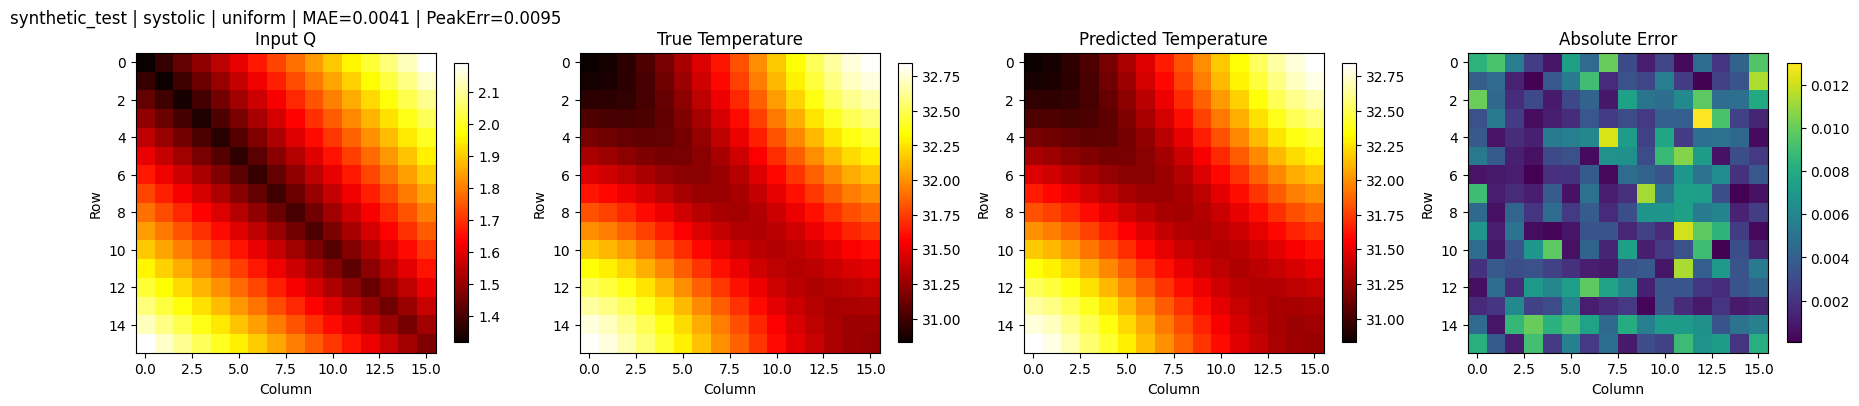

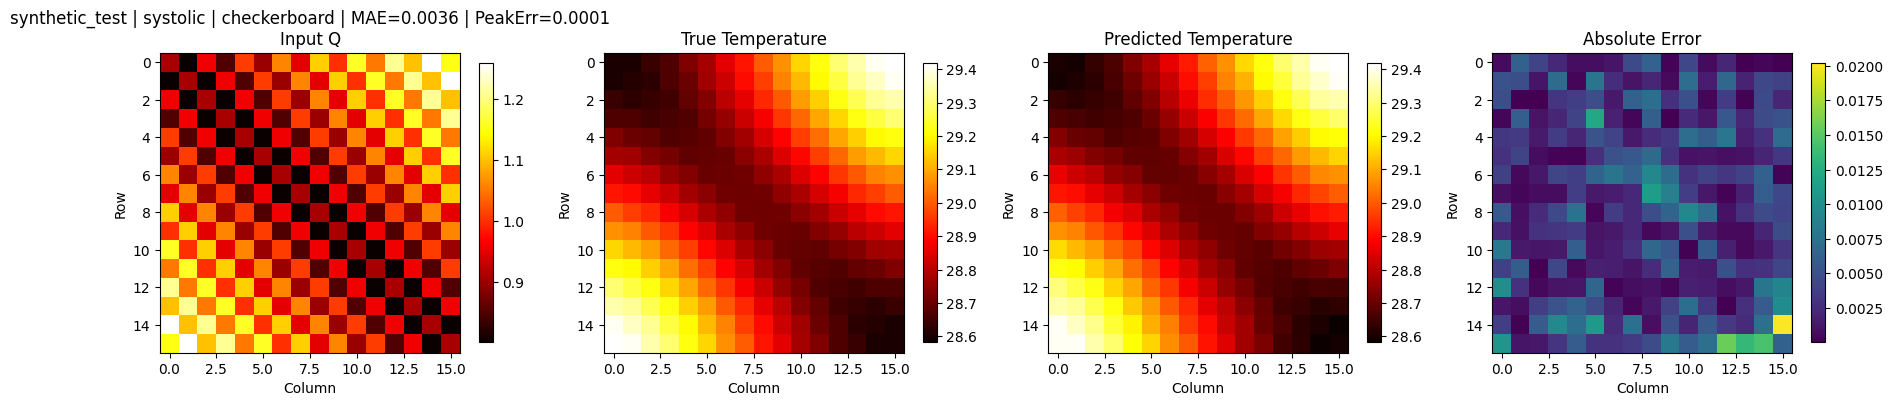

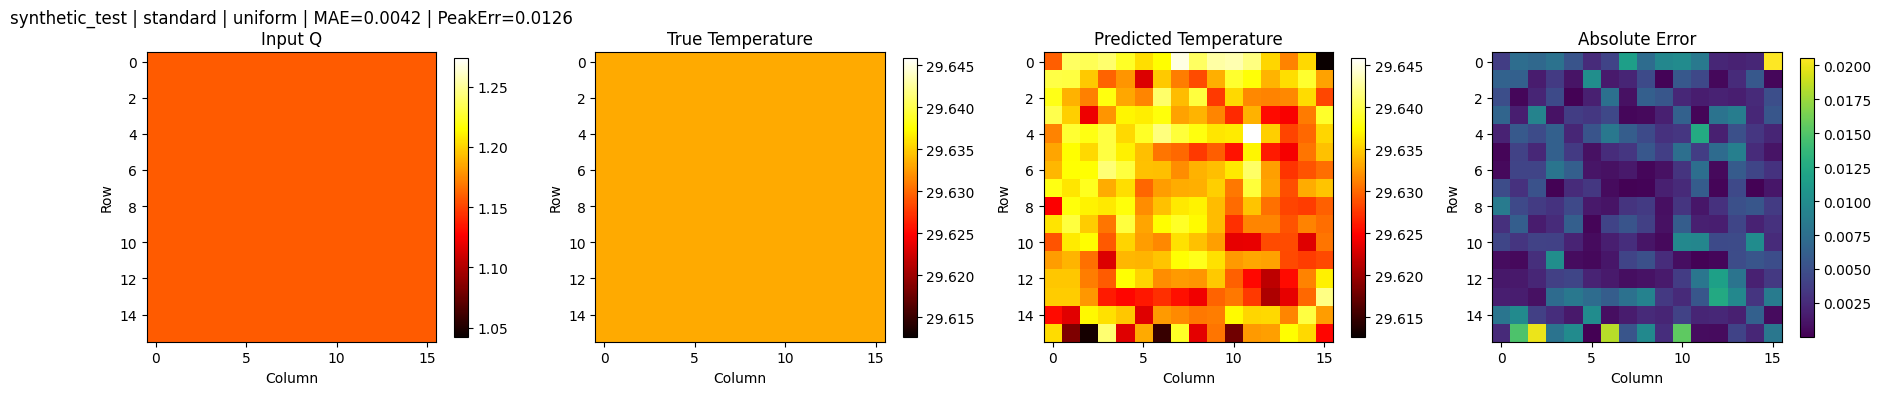


Predictions on real anchor cases:


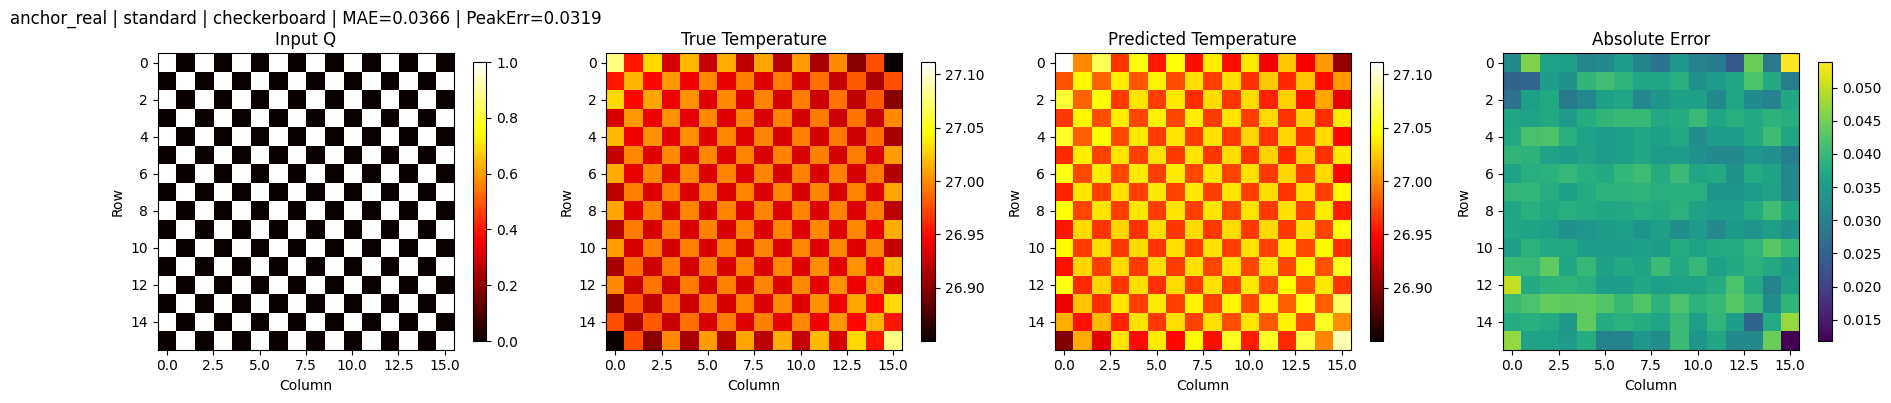

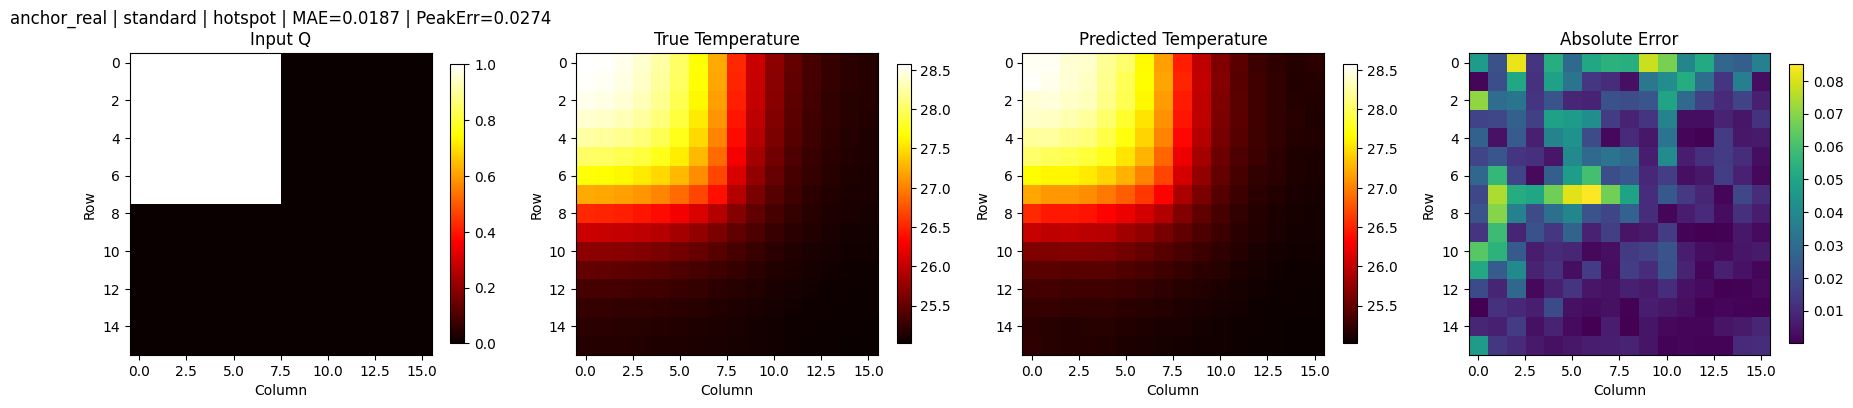

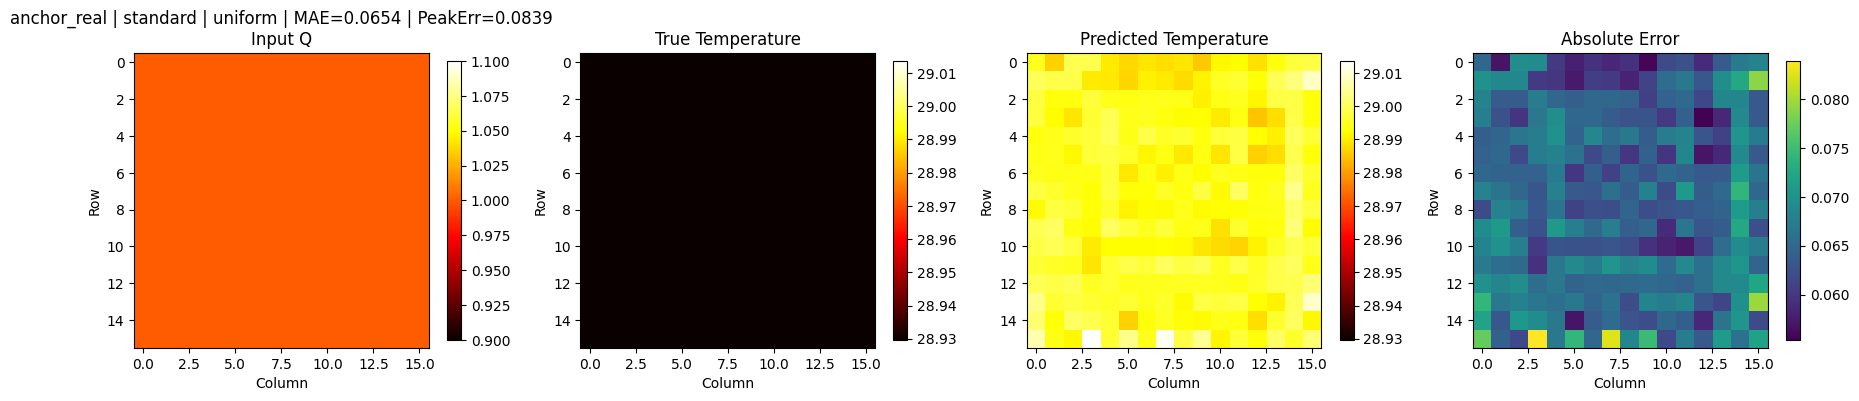

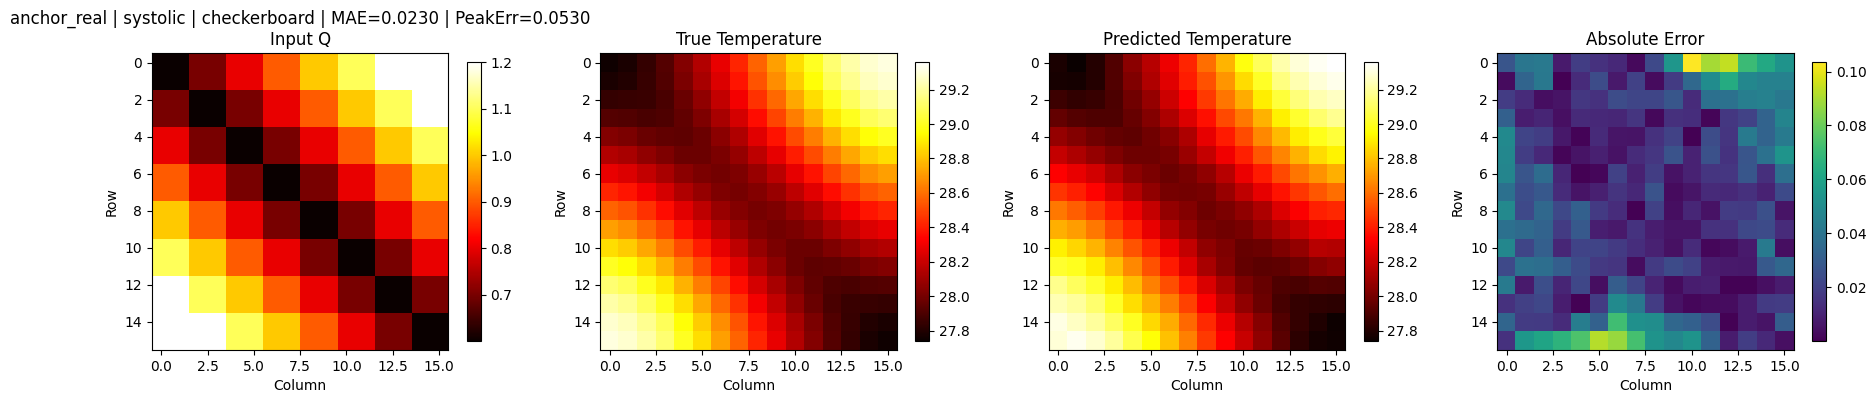

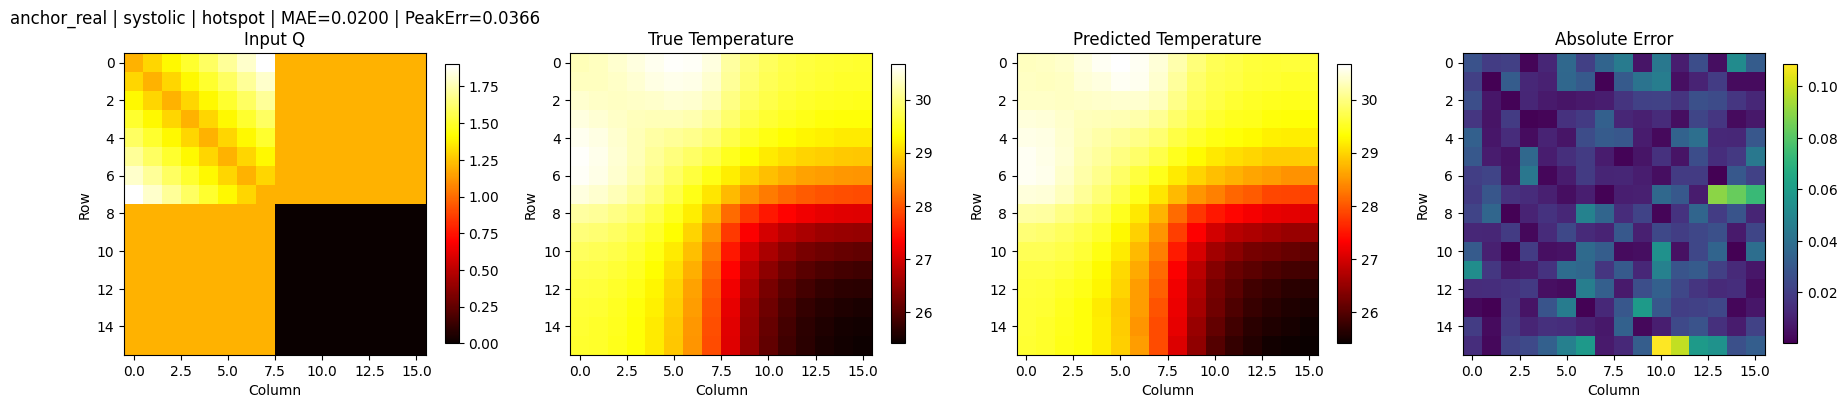

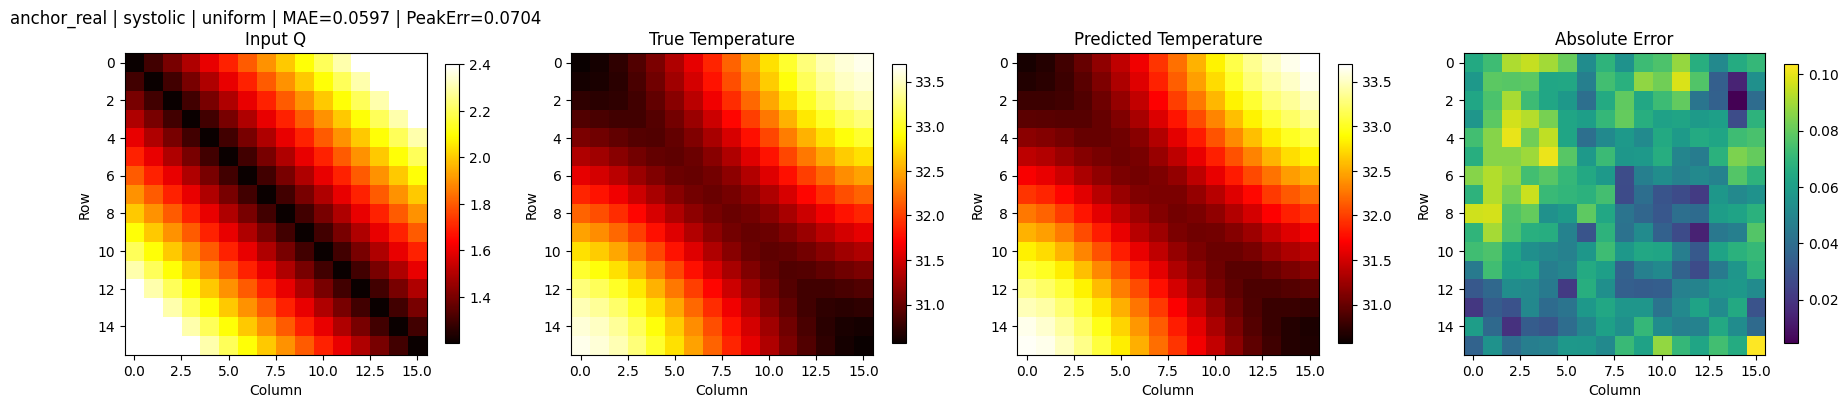


Saved evaluation CSVs to: /home/aditya_chaudhry/thermal_aware_mac/results/cnn_pinn/evaluation_16x16


In [9]:
# --------------------------------------------------
# Cell 8: Evaluation on synthetic test set + real anchors
# --------------------------------------------------
from math import sqrt

def denorm_dT(t_norm):
    return t_norm * Y_std + Y_mean

def rmse_np(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def mae_np(a, b):
    return float(np.mean(np.abs(a - b)))

def evaluate_loader_with_predictions(model, loader, subset_indices=None, split_name="split"):
    """
    Runs inference and returns:
    - per-sample metrics dataframe
    - lists of Q, true dT, pred dT, true T, pred T, abs error
    """
    model.eval()

    records = []
    q_list = []
    true_dt_list = []
    pred_dt_list = []
    true_t_list = []
    pred_t_list = []
    err_list = []

    sample_counter = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)

            # normalized -> physical
            q_phys = xb * X_std + X_mean
            true_dt = denorm_dT(yb)
            pred_dt = denorm_dT(pred)

            true_T = T_AMB + true_dt
            pred_T = T_AMB + pred_dt
            abs_err = torch.abs(pred_T - true_T)

            bs = xb.size(0)

            for i in range(bs):
                q_np = q_phys[i, 0].detach().cpu().numpy()
                true_dt_np = true_dt[i, 0].detach().cpu().numpy()
                pred_dt_np = pred_dt[i, 0].detach().cpu().numpy()
                true_t_np = true_T[i, 0].detach().cpu().numpy()
                pred_t_np = pred_T[i, 0].detach().cpu().numpy()
                err_np = abs_err[i, 0].detach().cpu().numpy()

                peak_true = float(np.max(true_t_np))
                peak_pred = float(np.max(pred_t_np))
                min_true = float(np.min(true_t_np))
                min_pred = float(np.min(pred_t_np))
                grad_true = peak_true - min_true
                grad_pred = peak_pred - min_pred

                rec = {
                    "split": split_name,
                    "sample_id": sample_counter,
                    "mae_temp": mae_np(pred_t_np, true_t_np),
                    "rmse_temp": rmse_np(pred_t_np, true_t_np),
                    "max_abs_error": float(np.max(err_np)),
                    "peak_true": peak_true,
                    "peak_pred": peak_pred,
                    "peak_abs_error": abs(peak_pred - peak_true),
                    "avg_true": float(np.mean(true_t_np)),
                    "avg_pred": float(np.mean(pred_t_np)),
                    "avg_abs_error": abs(float(np.mean(pred_t_np)) - float(np.mean(true_t_np))),
                    "grad_true": grad_true,
                    "grad_pred": grad_pred,
                    "grad_abs_error": abs(grad_pred - grad_true),
                }

                # attach metadata if subset indices are available
                if subset_indices is not None:
                    global_idx = subset_indices[sample_counter]
                    meta_row = meta_df.iloc[global_idx]
                    rec["architecture"] = meta_row["architecture"]
                    rec["workload"] = meta_row["workload"]
                    rec["N"] = int(meta_row["N"])
                    rec["source"] = meta_row["source"]

                records.append(rec)

                q_list.append(q_np)
                true_dt_list.append(true_dt_np)
                pred_dt_list.append(pred_dt_np)
                true_t_list.append(true_t_np)
                pred_t_list.append(pred_t_np)
                err_list.append(err_np)

                sample_counter += 1

    metrics_df = pd.DataFrame(records)
    return metrics_df, q_list, true_dt_list, pred_dt_list, true_t_list, pred_t_list, err_list


def summarize_metrics(metrics_df, name):
    print(f"\n{name} summary")
    print("-" * (len(name) + 8))
    summary = {
        "samples": len(metrics_df),
        "MAE(temp)": metrics_df["mae_temp"].mean(),
        "RMSE(temp)": metrics_df["rmse_temp"].mean(),
        "Max abs error": metrics_df["max_abs_error"].mean(),
        "Peak abs error": metrics_df["peak_abs_error"].mean(),
        "Avg abs error": metrics_df["avg_abs_error"].mean(),
        "Grad abs error": metrics_df["grad_abs_error"].mean(),
    }
    for k, v in summary.items():
        if isinstance(v, (int, np.integer)):
            print(f"{k:>16}: {v}")
        else:
            print(f"{k:>16}: {v:.6f}")


def plot_prediction_triplet(Q, T_true, T_pred, T_err, title_prefix="", annotate=False):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    im0 = axes[0].imshow(Q, cmap="hot", interpolation="nearest")
    axes[0].set_title(f"{title_prefix}\nInput Q")
    axes[0].set_xlabel("Column")
    axes[0].set_ylabel("Row")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    vmin = min(np.min(T_true), np.min(T_pred))
    vmax = max(np.max(T_true), np.max(T_pred))

    im1 = axes[1].imshow(T_true, cmap="hot", interpolation="nearest", vmin=vmin, vmax=vmax)
    axes[1].set_title("True Temperature")
    axes[1].set_xlabel("Column")
    axes[1].set_ylabel("Row")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    im2 = axes[2].imshow(T_pred, cmap="hot", interpolation="nearest", vmin=vmin, vmax=vmax)
    axes[2].set_title("Predicted Temperature")
    axes[2].set_xlabel("Column")
    axes[2].set_ylabel("Row")
    plt.colorbar(im2, ax=axes[2], shrink=0.8)

    im3 = axes[3].imshow(T_err, cmap="viridis", interpolation="nearest")
    axes[3].set_title("Absolute Error")
    axes[3].set_xlabel("Column")
    axes[3].set_ylabel("Row")
    plt.colorbar(im3, ax=axes[3], shrink=0.8)

    if annotate and Q.shape[0] <= 8:
        for ax, arr in zip(axes, [Q, T_true, T_pred, T_err]):
            for i in range(arr.shape[0]):
                for j in range(arr.shape[1]):
                    ax.text(j, i, f"{arr[i,j]:.2f}", ha="center", va="center", fontsize=6)

    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# Evaluate on held-out synthetic test split
# --------------------------------------------------
test_metrics_df, test_qs, test_true_dts, test_pred_dts, test_true_ts, test_pred_ts, test_errs = \
    evaluate_loader_with_predictions(
        model,
        stage1_test_loader,
        subset_indices=stage1_test_set.indices,
        split_name="synthetic_test"
    )

summarize_metrics(test_metrics_df, "Synthetic test set")
display(test_metrics_df.head())


# --------------------------------------------------
# Evaluate on real anchors
# --------------------------------------------------
anchor_metrics_df, anchor_qs, anchor_true_dts, anchor_pred_dts, anchor_true_ts, anchor_pred_ts, anchor_errs = \
    evaluate_loader_with_predictions(
        model,
        anchor_eval_loader,
        subset_indices=anchor_eval_set.indices,
        split_name="anchor_real"
    )

summarize_metrics(anchor_metrics_df, "Real anchor set")
display(anchor_metrics_df)


# --------------------------------------------------
# Grouped summaries
# --------------------------------------------------
print("\nSynthetic test metrics by architecture/workload:")
display(
    test_metrics_df.groupby(["architecture", "workload"])[
        ["mae_temp", "rmse_temp", "max_abs_error", "peak_abs_error", "grad_abs_error"]
    ].mean().round(6)
)

print("\nAnchor metrics by architecture/workload:")
display(
    anchor_metrics_df.groupby(["architecture", "workload"])[
        ["mae_temp", "rmse_temp", "max_abs_error", "peak_abs_error", "grad_abs_error"]
    ].mean().round(6)
)


# --------------------------------------------------
# Plot a few synthetic test predictions
# --------------------------------------------------
print("\nExample predictions from synthetic test set:")
for idx in [0, min(1, len(test_qs)-1), min(2, len(test_qs)-1)]:
    row = test_metrics_df.iloc[idx]
    title = (
        f"synthetic_test | {row['architecture']} | {row['workload']} | "
        f"MAE={row['mae_temp']:.4f} | PeakErr={row['peak_abs_error']:.4f}"
    )
    plot_prediction_triplet(
        test_qs[idx],
        test_true_ts[idx],
        test_pred_ts[idx],
        test_errs[idx],
        title_prefix=title,
        annotate=False
    )


# --------------------------------------------------
# Plot all real anchor predictions
# --------------------------------------------------
print("\nPredictions on real anchor cases:")
for idx in range(len(anchor_qs)):
    row = anchor_metrics_df.iloc[idx]
    title = (
        f"anchor_real | {row['architecture']} | {row['workload']} | "
        f"MAE={row['mae_temp']:.4f} | PeakErr={row['peak_abs_error']:.4f}"
    )
    plot_prediction_triplet(
        anchor_qs[idx],
        anchor_true_ts[idx],
        anchor_pred_ts[idx],
        anchor_errs[idx],
        title_prefix=title,
        annotate=False
    )


# --------------------------------------------------
# Save metrics
# --------------------------------------------------
cnn_eval_dir = CNN_PINN_DIR / "evaluation_16x16"
cnn_eval_dir.mkdir(parents=True, exist_ok=True)

test_metrics_df.to_csv(cnn_eval_dir / "synthetic_test_metrics.csv", index=False)
anchor_metrics_df.to_csv(cnn_eval_dir / "anchor_metrics.csv", index=False)

print("\nSaved evaluation CSVs to:", cnn_eval_dir)
